## 1. Query high-quality DESI DR1 galaxies

In [4]:
from io import StringIO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.esa.euclid import Euclid

project_root = Path(r"D:\AST\07_Euclid_Q1_Case_Study")
field_ra, field_dec, search_radius_deg = 267.78, 65.53, 0.25
desi_query_url = "https://datalab.noirlab.edu/query/query"

desi_query = f"""
SELECT
    targetid,
    mean_fiber_ra AS ra,
    mean_fiber_dec AS dec,
    z AS z_desi,
    zerr AS zerr_desi,
    zwarn,
    spectype,
    deltachi2,
    coadd_fiberstatus,
    survey,
    program,
    coadd_numexp,
    zcat_primary
FROM desi_dr1.zpix
WHERE 't' = Q3C_RADIAL_QUERY(mean_fiber_ra, mean_fiber_dec, {field_ra}, {field_dec}, {search_radius_deg})
    AND zwarn = 0
    AND spectype = 'GALAXY'
    AND coadd_fiberstatus = 0
LIMIT 5000
"""

desi_headers = {"X-DL-AuthToken": "anonymous.0.0.anon_access", "X-DL-TimeoutRequest": "180", "Content-Type": "text/ascii"}
desi_response = requests.get(desi_query_url, params={"sql": desi_query, "ofmt": "csv", "async": "False", "profile": "default"}, headers=desi_headers, timeout=180)
desi_response.raise_for_status()
if desi_response.text.lstrip().lower().startswith("error"):
    raise RuntimeError(desi_response.text[:1000])

desi_raw_df = pd.read_csv(StringIO(desi_response.text))
primary_mask = desi_raw_df["zcat_primary"].fillna(False).astype(str).str.strip().str.lower().isin(["true", "1", "t"])
desi_df = desi_raw_df.loc[primary_mask].drop_duplicates("targetid").copy()

print("DESI rows before primary selection:", len(desi_raw_df))
print("Primary high-quality galaxies:", len(desi_df))
print("Query reached LIMIT 5000:", len(desi_raw_df) == 5000)
desi_df.head(10)

DESI rows before primary selection: 1068
Primary high-quality galaxies: 970
Query reached LIMIT 5000: False


,targetid,ra,dec,z_desi,zerr_desi,zwarn,spectype,deltachi2,coadd_fiberstatus,survey,program,coadd_numexp,zcat_primary
0,39633448851211429,268.055314,65.620424,1.299713,0.000052,0,GALAXY,34.381192,0,sv3,dark,2,t
1,39633451351019764,267.535081,65.640737,1.127358,0.000126,0,GALAXY,35.533915,0,sv3,dark,3,t
2,39633448851211595,268.075198,65.619741,0.987841,0.000022,0,GALAXY,938.428533,0,sv3,dark,6,t
3,39633448847019981,267.813654,65.560871,0.761097,0.000132,0,GALAXY,35.991305,0,sv3,dark,6,t
4,39633451355212418,267.954937,65.712417,0.897754,0.000110,0,GALAXY,76.642041,0,sv3,dark,2,t
5,39633451355211667,267.854768,65.754257,0.892669,0.000153,0,GALAXY,283.748277,0,sv3,dark,2,t
6,39633451351019211,267.465466,65.684885,0.899519,0.000155,0,GALAXY,314.220486,0,sv3,dark,1,t
7,39633448847017179,267.461579,65.570805,0.624786,0.000020,0,GALAXY,3864.034337,0,sv3,dark,3,t
8,39633448842826094,267.252053,65.415608,0.824654,0.000140,0,GALAXY,214.537094,0,sv3,dark,1,t
9,39633451351020154,267.583195,65.738459,1.345457,0.000077,0,GALAXY,58.111780,0,sv3,dark,1,t


## 2. Query Euclid photometric redshifts in the DESI field

In [6]:
euclid_query = f"""
SELECT TOP 200000
    m.object_id,
    m.right_ascension,
    m.declination,
    m.vis_det,
    m.spurious_flag,
    m.det_quality_flag,
    m.flux_vis_sersic,
    m.flux_y_sersic,
    m.flux_j_sersic,
    m.flux_h_sersic,
    p.phz_median
FROM catalogue.mer_catalogue AS m
INNER JOIN catalogue.phz_photo_z AS p ON m.object_id = p.object_id
WHERE DISTANCE({field_ra}, {field_dec}, m.right_ascension, m.declination) < {search_radius_deg}
    AND m.spurious_flag = 0
    AND p.phz_median > 0
    AND p.phz_median < 4
"""

euclid_job = Euclid.launch_job_async(query=euclid_query)
euclid_table = euclid_job.get_results()
euclid_df = euclid_table.to_pandas().drop_duplicates("object_id").copy()

print("Euclid PHZ objects:", len(euclid_df))
print("Query reached TOP 200000 limit:", len(euclid_table) == 200000)
euclid_df.head(10)

INFO: Query finished. [astroquery.utils.tap.core]
Euclid PHZ objects: 83824
Query reached TOP 200000 limit: False


,object_id,right_ascension,declination,vis_det,spurious_flag,det_quality_flag,flux_vis_sersic,flux_y_sersic,flux_j_sersic,flux_h_sersic,phz_median
0,2680473103653102608,268.047310,65.310261,1,0,0,2.124582,4.402863,4.246638,4.840266,0.29
1,2680195555653212956,268.019556,65.321296,1,0,2,2.663456,4.411747,4.789797,5.188339,0.72
2,2681314039653292116,268.131404,65.329212,1,0,0,0.156216,0.192339,0.214767,0.237958,3.44
3,2680974871653374186,268.097487,65.337419,1,0,0,0.160932,0.289533,0.325274,0.557842,2.89
4,2681028887653526203,268.102889,65.352620,1,0,0,1.386085,2.608603,3.039493,3.299534,0.54
5,2681026243653537640,268.102624,65.353764,1,0,0,1.165057,3.279053,3.972291,4.527330,1.61
6,2681006459653587660,268.100646,65.358766,1,0,0,0.311541,0.911657,1.306237,1.264952,0.99
7,2680454150653590233,268.045415,65.359023,1,0,0,0.175505,0.307098,0.463210,0.542459,1.61
8,2680659461653608472,268.065946,65.360847,1,0,0,0.117220,0.410535,0.453798,0.554663,2.97
9,2680619601653660360,268.061960,65.366036,1,0,0,0.523464,1.220240,1.651402,1.936417,0.30


## 3. Cross-match DESI and Euclid sources

In [8]:
%pip install scipy

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [9]:
desi_coord = SkyCoord(ra=desi_df["ra"].to_numpy() * u.deg, dec=desi_df["dec"].to_numpy() * u.deg)
euclid_coord = SkyCoord(ra=euclid_df["right_ascension"].to_numpy() * u.deg, dec=euclid_df["declination"].to_numpy() * u.deg)

nearest_index, separation_2d, _ = desi_coord.match_to_catalog_sky(euclid_coord)
nearest_euclid_df = euclid_df.iloc[nearest_index].reset_index(drop=True).add_prefix("euclid_")
match_candidates_df = pd.concat([desi_df.reset_index(drop=True), nearest_euclid_df], axis=1)
match_candidates_df["separation_arcsec"] = separation_2d.arcsec

match_counts = pd.DataFrame({"radius_arcsec": [0.2, 0.3, 0.5, 1.0], "matches": [(match_candidates_df["separation_arcsec"] <= radius).sum() for radius in [0.2, 0.3, 0.5, 1.0]]})
match_radius_arcsec = 0.5
matched_df = match_candidates_df.loc[match_candidates_df["separation_arcsec"] <= match_radius_arcsec].sort_values("separation_arcsec").drop_duplicates("euclid_object_id").copy()

euclid_density_deg2 = len(euclid_df) / (np.pi * search_radius_deg**2)
random_match_probability = 1 - np.exp(-np.pi * (match_radius_arcsec / 3600)**2 * euclid_density_deg2)

print("DESI targets:", len(desi_df))
print("Euclid sources:", len(euclid_df))
print("Accepted unique matches:", len(matched_df))
print("Approximate random-match probability at 0.5 arcsec:", f"{100 * random_match_probability:.2f}%")
display(match_counts)
matched_df[["targetid", "euclid_object_id", "z_desi", "euclid_phz_median", "separation_arcsec"]].head(10)

DESI targets: 970
Euclid sources: 83824
Accepted unique matches: 885
Approximate random-match probability at 0.5 arcsec: 2.55%


,radius_arcsec,matches
0,0.2,701
1,0.3,828
2,0.5,888
3,1.0,916


,targetid,euclid_object_id,z_desi,euclid_phz_median,separation_arcsec
38,39633448851213590,2683349434655583045,0.156701,0.15,0.007849
724,39633448851212393,2681813572653891430,0.862681,0.83,0.007928
509,39633446322045032,2679272619652967226,0.733566,0.13,0.008483
234,39633448851213558,2683302017654752123,0.713526,0.70,0.008563
381,39633448847016707,2674012898655158603,0.823443,0.81,0.008663
148,39633451351019579,2675122810656644563,0.188682,0.14,0.009067
932,39633451355210481,2676747318657477334,0.983952,1.05,0.009806
605,39633451351018422,2673652609656627263,0.821597,1.02,0.010078
46,39633451355211848,2678801197657093101,0.088952,0.08,0.011462
382,39633448847016921,2674277542656031773,0.088370,0.06,0.011820


## 4. Measure Euclid photo-z performance against DESI

In [10]:
validation_df = matched_df.dropna(subset=["z_desi", "euclid_phz_median"]).copy()
validation_df = validation_df[validation_df["z_desi"].between(0, 4, inclusive="neither")].copy()
validation_df["delta_z"] = validation_df["euclid_phz_median"] - validation_df["z_desi"]
validation_df["delta_z_normalized"] = validation_df["delta_z"] / (1 + validation_df["z_desi"])
validation_df["photoz_outlier"] = validation_df["delta_z_normalized"].abs() > 0.15

def summarize_photoz(frame):
    residual = frame["delta_z_normalized"].to_numpy()
    bias = np.median(residual)
    return pd.Series({"galaxies": len(frame), "bias": bias, "nmad": 1.4826 * np.median(np.abs(residual - bias)), "rmse": np.sqrt(np.mean(residual**2)), "outlier_percent": 100 * np.mean(np.abs(residual) > 0.15)})

validation_samples = {
    "all_matches_0p5": validation_df,
    "tight_matches_0p3": validation_df[validation_df["separation_arcsec"] <= 0.3],
    "target_range_0p9_1p8": validation_df[validation_df["z_desi"].between(0.9, 1.8)]
}
metrics_df = pd.DataFrame({name: summarize_photoz(frame) for name, frame in validation_samples.items()}).T

print("Valid matched galaxies:", len(validation_df))
print("DESI redshift range:", validation_df["z_desi"].min(), validation_df["z_desi"].max())
metrics_df

Valid matched galaxies: 884
DESI redshift range: 0.0272114723881539 1.622510396724233


,galaxies,bias,nmad,rmse,outlier_percent
all_matches_0p5,884.0,-0.013152,0.040771,0.193731,6.674208
tight_matches_0p3,826.0,-0.013008,0.040691,0.190133,6.174334
target_range_0p9_1p8,251.0,-0.008838,0.040843,0.117226,8.764940


## 5. Visualize the external photo-z validation

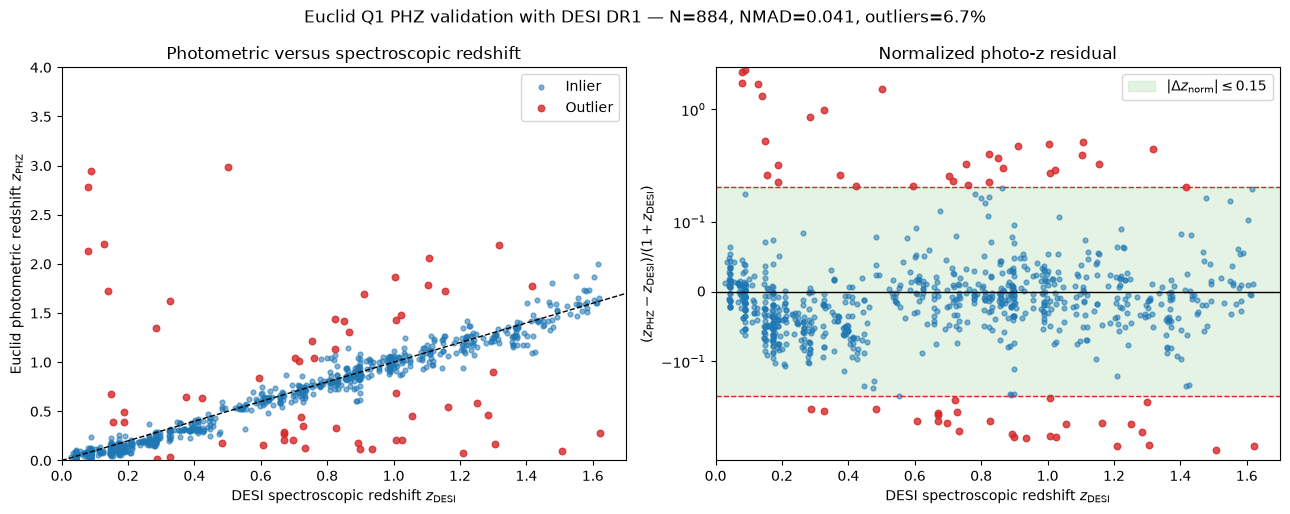

Saved figure: D:\AST\07_Euclid_Q1_Case_Study\outputs\figures\euclid_desi_photoz_validation.png


In [11]:
inlier_df = validation_df.loc[~validation_df["photoz_outlier"]]
outlier_df = validation_df.loc[validation_df["photoz_outlier"]]
figure_path = project_root / "outputs" / "figures" / "euclid_desi_photoz_validation.png"

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

axes[0].scatter(inlier_df["z_desi"], inlier_df["euclid_phz_median"], s=12, alpha=0.55, color="tab:blue", label="Inlier")
axes[0].scatter(outlier_df["z_desi"], outlier_df["euclid_phz_median"], s=22, alpha=0.8, color="tab:red", label="Outlier")
axes[0].plot([0, 4], [0, 4], linestyle="--", color="black", linewidth=1)
axes[0].set(xlabel=r"DESI spectroscopic redshift $z_{\rm DESI}$", ylabel=r"Euclid photometric redshift $z_{\rm PHZ}$", xlim=(0, 1.7), ylim=(0, 4), title="Photometric versus spectroscopic redshift")
axes[0].legend()

axes[1].axhspan(-0.15, 0.15, color="tab:green", alpha=0.12, label=r"$|\Delta z_{\rm norm}|\leq0.15$")
axes[1].scatter(inlier_df["z_desi"], inlier_df["delta_z_normalized"], s=12, alpha=0.55, color="tab:blue")
axes[1].scatter(outlier_df["z_desi"], outlier_df["delta_z_normalized"], s=22, alpha=0.8, color="tab:red")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhline(0.15, color="tab:red", linestyle="--", linewidth=1)
axes[1].axhline(-0.15, color="tab:red", linestyle="--", linewidth=1)
axes[1].set_yscale("symlog", linthresh=0.15)
axes[1].set(xlabel=r"DESI spectroscopic redshift $z_{\rm DESI}$", ylabel=r"$(z_{\rm PHZ}-z_{\rm DESI})/(1+z_{\rm DESI})$", xlim=(0, 1.7), title="Normalized photo-z residual")
axes[1].legend()

fig.suptitle(f"Euclid Q1 PHZ validation with DESI DR1 — N={len(validation_df)}, NMAD={metrics_df.loc['all_matches_0p5', 'nmad']:.3f}, outliers={metrics_df.loc['all_matches_0p5', 'outlier_percent']:.1f}%")
fig.tight_layout()
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## 6. Diagnose the catastrophic photo-z outliers

In [12]:
photometry_columns = ["euclid_flux_vis_sersic", "euclid_flux_y_sersic", "euclid_flux_j_sersic", "euclid_flux_h_sersic"]
validation_df[photometry_columns] = validation_df[photometry_columns].apply(pd.to_numeric, errors="coerce")

validation_df["h_ab_mag"] = np.nan
validation_df["vis_minus_h"] = np.nan
positive_h = validation_df["euclid_flux_h_sersic"] > 0
positive_vis_h = (validation_df["euclid_flux_vis_sersic"] > 0) & positive_h
validation_df.loc[positive_h, "h_ab_mag"] = 23.9 - 2.5 * np.log10(validation_df.loc[positive_h, "euclid_flux_h_sersic"])
validation_df.loc[positive_vis_h, "vis_minus_h"] = -2.5 * np.log10(validation_df.loc[positive_vis_h, "euclid_flux_vis_sersic"] / validation_df.loc[positive_vis_h, "euclid_flux_h_sersic"])

def summarize_source_properties(frame):
    return pd.Series({
        "galaxies": len(frame),
        "median_separation_arcsec": frame["separation_arcsec"].median(),
        "median_h_ab_mag": frame["h_ab_mag"].median(),
        "median_vis_minus_h": frame["vis_minus_h"].median(),
        "valid_vis_h_percent": 100 * frame["vis_minus_h"].notna().mean(),
        "nonzero_quality_flag_percent": 100 * (frame["euclid_det_quality_flag"] != 0).mean(),
        "vis_detection_percent": 100 * (frame["euclid_vis_det"] == 1).mean(),
        "median_deltachi2": frame["deltachi2"].median()
    })

source_diagnostics_df = pd.DataFrame({
    "inliers": summarize_source_properties(validation_df.loc[~validation_df["photoz_outlier"]]),
    "outliers": summarize_source_properties(validation_df.loc[validation_df["photoz_outlier"]])
}).T

source_diagnostics_df

,galaxies,median_separation_arcsec,median_h_ab_mag,median_vis_minus_h,valid_vis_h_percent,nonzero_quality_flag_percent,vis_detection_percent,median_deltachi2
inliers,825.0,0.127165,19.459749,1.236199,100.0,37.696970,100.0,380.354523
outliers,59.0,0.129141,22.056413,0.942737,100.0,40.677966,100.0,255.577825


## 7. Measure the outlier fraction as a function of H-band magnitude

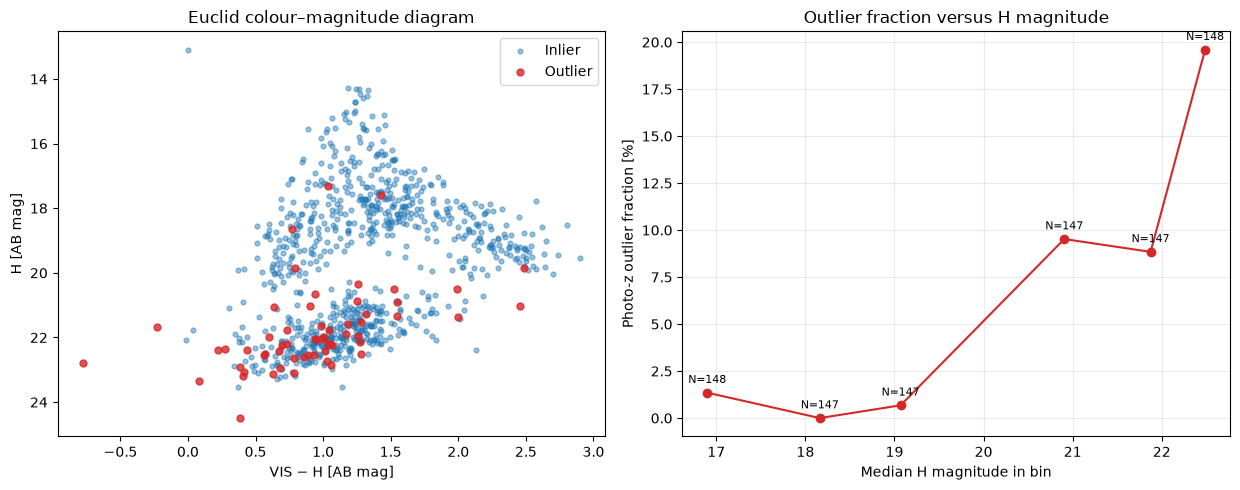

Saved figure: D:\AST\07_Euclid_Q1_Case_Study\outputs\figures\euclid_desi_photoz_outlier_diagnostics.png


,h_mag_bin,h_median,galaxies,outlier_percent
0,"(13.096, 17.713]",16.898715,148,1.351351
1,"(17.713, 18.579]",18.162100,147,0.000000
2,"(18.579, 19.707]",19.068816,147,0.680272
3,"(19.707, 21.47]",20.905560,147,9.523810
4,"(21.47, 22.131]",21.874609,147,8.843537
5,"(22.131, 24.494]",22.486451,148,19.594595


In [14]:
brightness_inlier_df = brightness_df.loc[~brightness_df["photoz_outlier"]]
brightness_outlier_df = brightness_df.loc[brightness_df["photoz_outlier"]]
brightness_df["h_mag_bin"] = pd.qcut(brightness_df["h_ab_mag"], q=6, duplicates="drop")
outlier_by_h_df = brightness_df.groupby("h_mag_bin", observed=True).agg(h_median=("h_ab_mag", "median"), galaxies=("photoz_outlier", "size"), outlier_percent=("photoz_outlier", lambda values: 100 * values.mean())).reset_index()

figure_path = project_root / "outputs" / "figures" / "euclid_desi_photoz_outlier_diagnostics.png"
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

axes[0].scatter(brightness_inlier_df["vis_minus_h"], brightness_inlier_df["h_ab_mag"], s=12, alpha=0.45, color="tab:blue", label="Inlier")
axes[0].scatter(brightness_outlier_df["vis_minus_h"], brightness_outlier_df["h_ab_mag"], s=25, alpha=0.8, color="tab:red", label="Outlier")
axes[0].invert_yaxis()
axes[0].set(xlabel="VIS − H [AB mag]", ylabel="H [AB mag]", title="Euclid colour–magnitude diagram")
axes[0].legend()

axes[1].plot(outlier_by_h_df["h_median"], outlier_by_h_df["outlier_percent"], marker="o", color="tab:red")
for _, row in outlier_by_h_df.iterrows():
    axes[1].annotate(f"N={int(row['galaxies'])}", (row["h_median"], row["outlier_percent"]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
axes[1].set(xlabel="Median H magnitude in bin", ylabel="Photo-z outlier fraction [%]", title="Outlier fraction versus H magnitude")
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)
outlier_by_h_df

## 8. Save the external validation results

In [17]:
matched_output_path = project_root / "outputs" / "tables" / "euclid_desi_matched_photoz_validation.csv"
metrics_output_path = project_root / "outputs" / "tables" / "euclid_desi_photoz_metrics.csv"

output_columns = ["targetid", "euclid_object_id", "ra", "dec", "z_desi", "zerr_desi", "euclid_phz_median", "delta_z", "delta_z_normalized", "photoz_outlier", "separation_arcsec", "h_ab_mag", "vis_minus_h", "euclid_det_quality_flag", "deltachi2", "survey", "program"]
validation_df[output_columns].to_csv(matched_output_path, index=False)
metrics_df.to_csv(metrics_output_path)

print("Saved matched catalogue:", matched_output_path)
print("Saved validation metrics:", metrics_output_path)
print("Final matched galaxies:", len(validation_df))

Saved matched catalogue: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\euclid_desi_matched_photoz_validation.csv
Saved validation metrics: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\euclid_desi_photoz_metrics.csv
Final matched galaxies: 884
